In [6]:
#Carga de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print ("Librerías cargadas correctamente!")

Librerías cargadas correctamente!


In [3]:
#Carga de dataframe de datos de videojuegos y análisis preliminar (Valores nulos, tipos de datos y datos iniciales)
df = pd.read_csv('09. videojuegos.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())


    Nombre Plataforma  Anio_Lanzamiento      Genero  Ventas_NA  Ventas_EU  \
0  Juego_0       Xbox              2011    Aventura  13.516229   8.243746   
1  Juego_1   Nintendo              2019      Acción   9.533212   3.665887   
2  Juego_2         PC              2021    Aventura   5.151544   1.357899   
3  Juego_3       Xbox              2011  Estrategia   5.303223   5.270208   
4  Juego_4       Xbox              2019  Estrategia  10.916740   7.722936   

   Ventas_JP  Critica_Puntaje  
0   1.860090              NaN  
1   3.882065             97.0  
2   1.704018             67.0  
3   4.653787             75.0  
4   4.292064             65.0  
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nombre            100 non-null    str    
 1   Plataforma        100 non-null    str    
 2   Anio_Lanzamiento  100 non-null    int64  
 3   Genero       

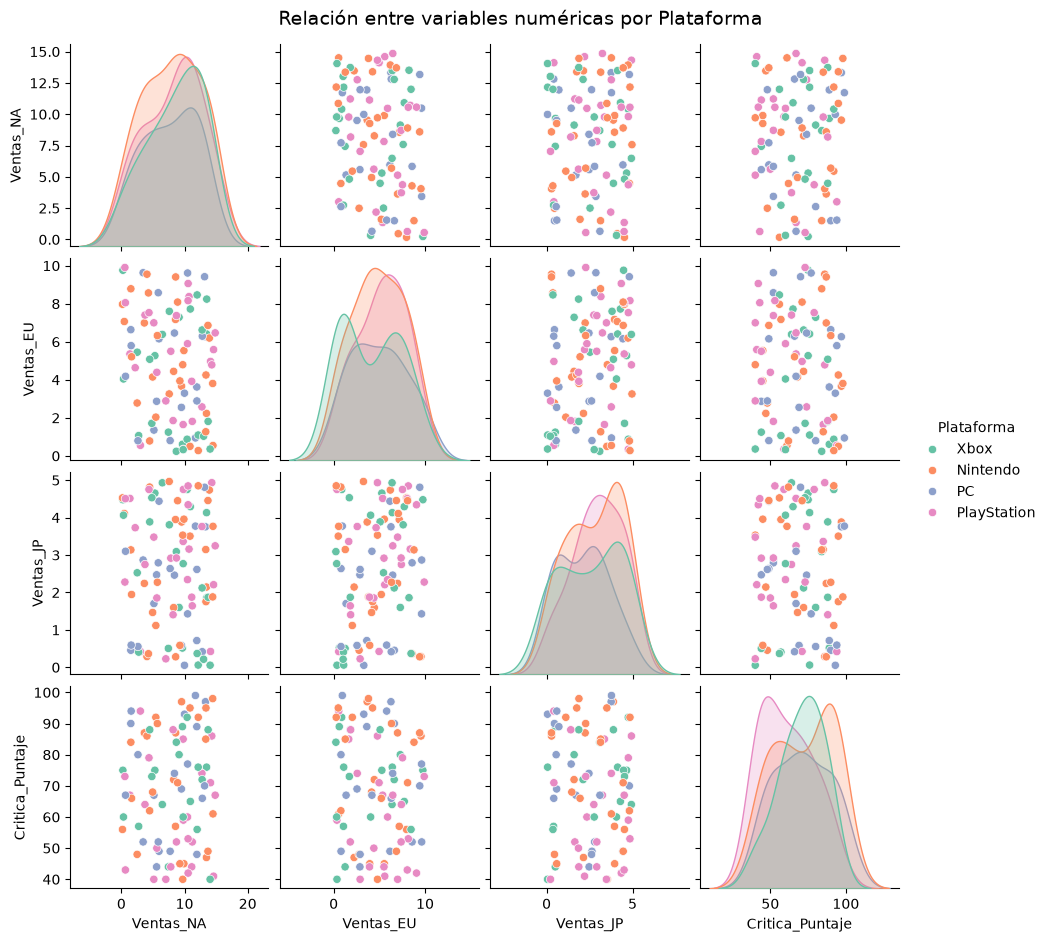

In [7]:
#Análisis visual con Seaborn 1. 
#Pair plot de cada región identificada y cada plataforma de videojuegos.
variables_numericas = ["Ventas_NA", "Ventas_EU", "Ventas_JP", "Critica_Puntaje"]
pairplot = sns.pairplot(
    df,
    vars=variables_numericas,
    hue="Plataforma",
    diag_kind="kde",  
    palette="Set2",
    height=2.3
)
pairplot.fig.suptitle("Relación entre variables numéricas por Plataforma", y=1.02, fontsize=14)
plt.show()


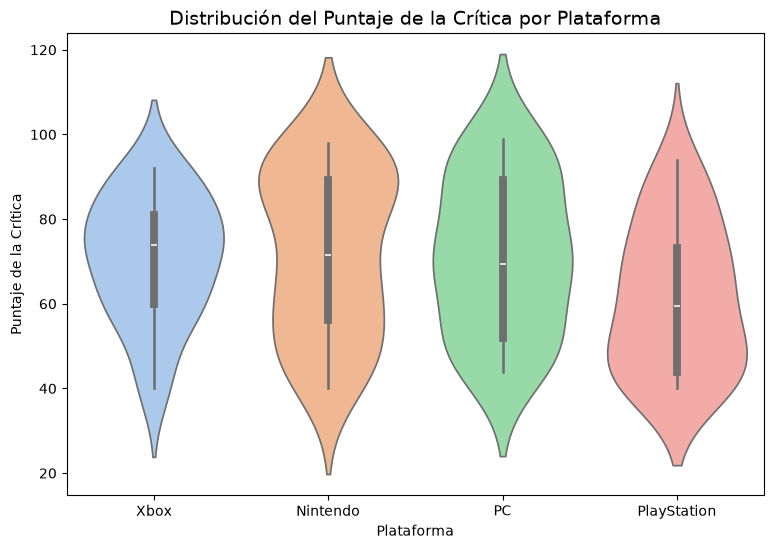

In [8]:
#Análisis visual con Seaborn 2.
#Distribución del puntaje de la crítica por plataforma de videojuegos.
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="Plataforma",
    y="Critica_Puntaje",
    hue="Plataforma",
    palette="pastel",
    legend=False
)

plt.title("Distribución del Puntaje de la Crítica por Plataforma", fontsize=14)
plt.xlabel("Plataforma")
plt.ylabel("Puntaje de la Crítica")
plt.show()


In [9]:
#Análisis visual con Seaborn 3.
#Matriz de correlación entre variables numéricas
matriz_correlacion = df[variables_numericas].corr()
print("Matriz de correlación entre variables numéricas:")
print(matriz_correlacion)

Matriz de correlación entre variables numéricas:
                 Ventas_NA  Ventas_EU  Ventas_JP  Critica_Puntaje
Ventas_NA         1.000000  -0.204332  -0.023772         0.040401
Ventas_EU        -0.204332   1.000000   0.180201        -0.121058
Ventas_JP        -0.023772   0.180201   1.000000        -0.071047
Critica_Puntaje   0.040401  -0.121058  -0.071047         1.000000


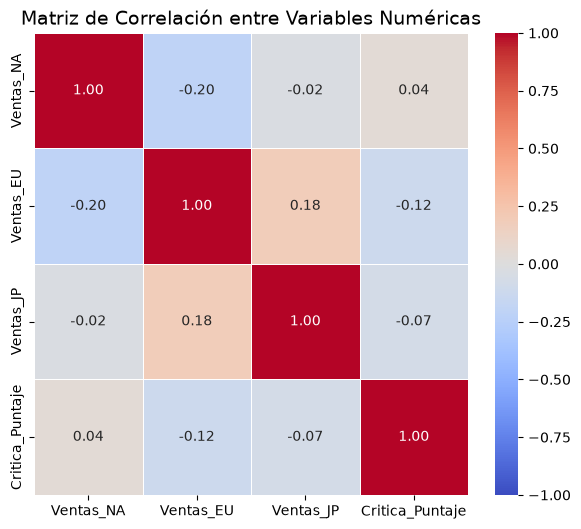

In [10]:
#Análisis visual con Seaborn 3.
#Mapa de calor de la matriz de correlación, se usa para visualizar la fuerza y dirección de las relaciones entre las variables numéricas.
plt.figure(figsize=(7, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,        
    fmt=".2f",          
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14)
plt.show()


In [ ]:
#Preparación de datos para análisis visual a través de gráficos de barras personalizado
#Ventas globales por juego (fila a fila)
df["Ventas_Globales"] = df["Ventas_NA"] + df["Ventas_EU"] + df["Ventas_JP"]
print("\nVentas globales por juego:")
print(df[["Nombre", "Ventas_Globales"]].head())
#Promedio de ventas globales agrupado por Genero
ventas_por_genero = df.groupby("Genero")["Ventas_Globales"].mean().sort_values(ascending=False)
print("\nPromedio de Ventas Globales por Género:")
print(ventas_por_genero)



Ventas globales por juego:
    Nombre  Ventas_Globales
0  Juego_0        23.620065
1  Juego_1        17.081164
2  Juego_2         8.213461
3  Juego_3        15.227218
4  Juego_4        22.931740

Promedio de Ventas Globales por Género:
Genero
Estrategia    16.835730
Acción        15.884657
RPG           15.784117
Deportes      14.800334
Aventura      12.376321
Name: Ventas_Globales, dtype: float64


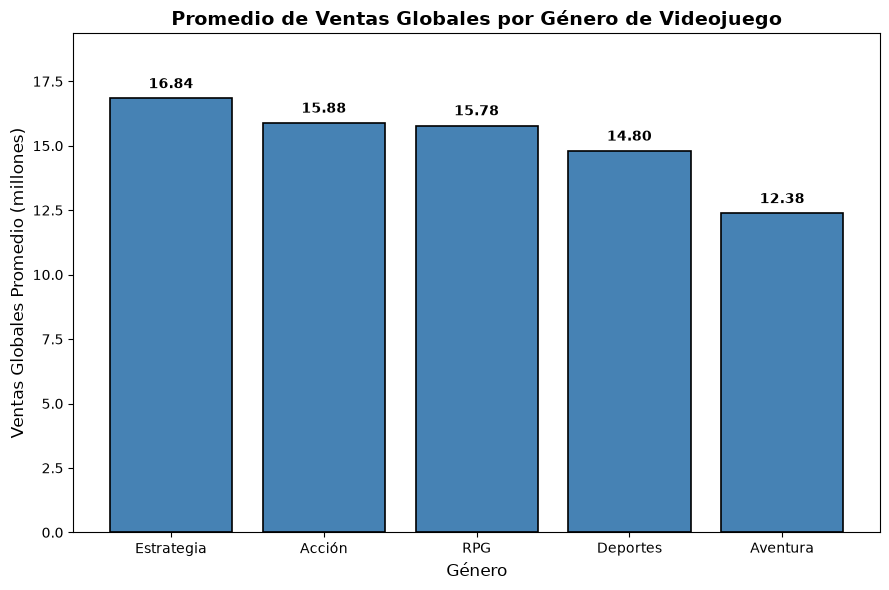

In [20]:
#Gráfico de barras personalizado para mostrar el promedio de ventas globales por género de videojuegos
fig, ax = plt.subplots(figsize=(9, 6))

barras = ax.bar(
    ventas_por_genero.index,
    ventas_por_genero.values,
    color="steelblue",
    edgecolor="black",   # borde negro en las barras
    linewidth=1.2
)
ax.set_title("Promedio de Ventas Globales por Género de Videojuego", fontsize=14, fontweight="bold")
ax.set_xlabel("Género", fontsize=12)
ax.set_ylabel("Ventas Globales Promedio (millones)", fontsize=12)

maximo = ventas_por_genero.max()
ax.set_ylim(0, maximo * 1.15)

# Anotaciones con el valor exacto sobre cada barra
for barra in barras:
    altura = barra.get_height()
    ax.annotate(
        f"{altura:.2f}",
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 5),              
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )
plt.tight_layout()
plt.show()